# EDA Calendar Airbnb Málaga (2025–2026)
> **Práctica 1 - SDPD2 · GCID · URJC**  
> Análisis Exploratorio de Datos completo sobre el dataset `calendar.csv`

## 0. Imports y configuración

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo visual uniforme
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
ACCENT = '#E8504A'   # rojo Airbnb
BLUE   = '#3A86FF'
GREEN  = '#2DC653'

## 1. Carga y preparación de datos
*(igual que el notebook original, agrupado en una sola celda para mayor claridad)*

In [18]:
calendar = pd.read_csv('../data/calendar.csv')

# Tipos
calendar['date']      = pd.to_datetime(calendar['date'])
calendar['available'] = calendar['available'].map({'t': True, 'f': False})

# Eliminar columnas de precio (100 % nulas)
calendar.drop(columns=['price', 'adjusted_price'], inplace=True, errors='ignore')

# Variables temporales
calendar['month']       = calendar['date'].dt.month
calendar['month_name']  = calendar['date'].dt.strftime('%b %Y')
calendar['day_of_week'] = calendar['date'].dt.dayofweek          # 0=Lun … 6=Dom
calendar['day_name']    = calendar['date'].dt.day_name(locale='es_ES.UTF-8') if True else calendar['date'].dt.day_name()
calendar['is_weekend']  = calendar['day_of_week'].isin([5, 6]).astype(np.int8)   # Sab+Dom
calendar['week']        = calendar['date'].dt.isocalendar().week.astype(int)

# Eventos en Málaga
def check_event(date):
    if date.month == 8:                                                          return 'Feria de Málaga'
    if pd.Timestamp('2026-03-29') <= date <= pd.Timestamp('2026-04-05'):         return 'Semana Santa'
    if (date.month == 12 and date.day >= 20) or (date.month == 1 and date.day <= 6): return 'Navidad/Reyes'
    if date.month == 7:                                                          return 'Julio (alta temporada)'
    if date.month in [6, 9]:                                                     return 'Hombros de temporada'
    return 'Temporada normal'

calendar['event_type'] = calendar['date'].apply(check_event)

# Variable objetivo
calendar['is_booked']       = (~calendar['available']).astype(np.int8)
calendar['minimum_nights']  = calendar['minimum_nights'].astype(np.int32)
calendar['maximum_nights']  = calendar['maximum_nights'].astype(np.int32)

print(f'Shape: {calendar.shape}')
calendar.head()

Shape: (3545610, 13)


,listing_id,date,available,minimum_nights,maximum_nights,month,month_name,day_of_week,day_name,is_weekend,week,event_type,is_booked
0,6341180,2025-09-30,True,2,1125,9,Sep 2025,1,Martes,0,40,Hombros de temporada,0
1,6341180,2025-10-01,False,2,1125,10,Oct 2025,2,Miércoles,0,40,Temporada normal,1
2,6341180,2025-10-02,False,2,1125,10,Oct 2025,3,Jueves,0,40,Temporada normal,1
3,6341180,2025-10-03,False,2,1125,10,Oct 2025,4,Viernes,0,40,Temporada normal,1
4,6341180,2025-10-04,False,2,1125,10,Oct 2025,5,Sábado,1,40,Temporada normal,1


---
## 2. Visión general del dataset

In [19]:
print('=== RESUMEN GENERAL ===')
print(calendar.info())
print()
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
display(calendar.describe(include='all').T)

=== RESUMEN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 3545610 entries, 0 to 3545609
Data columns (total 13 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[us]
 2   available       bool          
 3   minimum_nights  int32         
 4   maximum_nights  int32         
 5   month           int32         
 6   month_name      str           
 7   day_of_week     int32         
 8   day_name        str           
 9   is_weekend      int8          
 10  week            int64         
 11  event_type      str           
 12  is_booked       int8          
dtypes: bool(1), datetime64[us](1), int32(4), int64(2), int8(2), str(3)
memory usage: 226.6 MB
None

=== ESTADÍSTICAS DESCRIPTIVAS ===


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
listing_id,3545610.0,NaN,NaN,NaN,710346931476111104.0,96033.0,43997600.0,852830654203864448.0,1206497382689735424.0,1520070219733116928.0,559866805081624256.0
date,3545610,NaN,NaN,NaN,2026-03-31 00:00:00,2025-09-30 00:00:00,2025-12-30 00:00:00,2026-03-31 00:00:00,2026-06-30 00:00:00,2026-09-29 00:00:00,NaN
available,3545610,2,True,2025248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minimum_nights,3545610.0,NaN,NaN,NaN,5.329076,1.0,2.0,3.0,4.0,500.0,17.273645
maximum_nights,3545610.0,NaN,NaN,NaN,656.373478,1.0,365.0,731.0,1125.0,1125.0,450.83234
month,3545610.0,NaN,NaN,NaN,6.526027,1.0,4.0,7.0,10.0,12.0,3.447852
month_name,3545610,13,Oct 2025,301134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,3545610.0,NaN,NaN,NaN,2.994521,0.0,1.0,3.0,5.0,6.0,1.999993
day_name,3545610,7,Martes,514842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_weekend,3545610.0,NaN,NaN,NaN,0.284932,0.0,0.0,0.0,1.0,1.0,0.451382


In [20]:
# Mapa de nulos
null_pct = calendar.isnull().mean() * 100
print('Porcentaje de nulos por columna:')
print(null_pct[null_pct > 0].to_string() if null_pct.any() else 'Sin valores nulos')

Porcentaje de nulos por columna:
Sin valores nulos


---
## 3. Ocupación global y tendencia temporal

### 3.1 Tasa de ocupación diaria

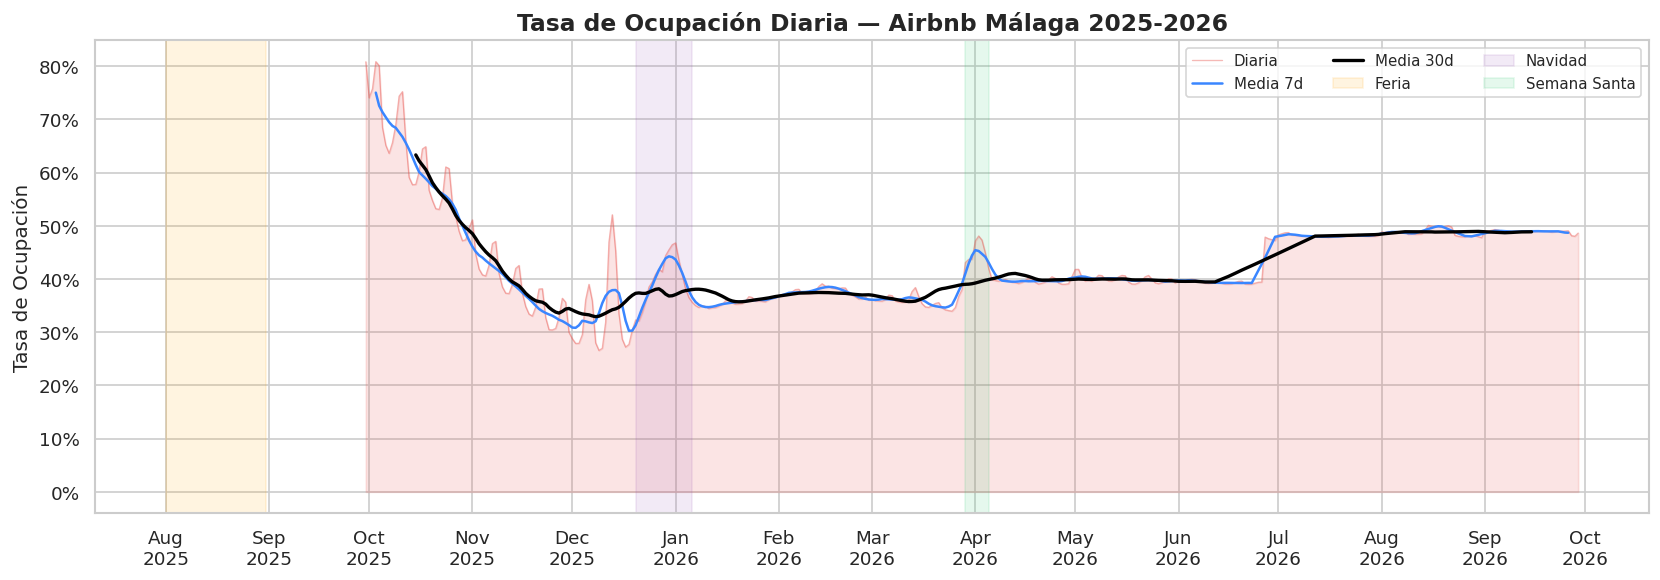

In [21]:
daily_occ = calendar.groupby('date')['is_booked'].mean()
daily_occ_7d  = daily_occ.rolling(7,  center=True).mean()
daily_occ_30d = daily_occ.rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_occ.index, daily_occ, alpha=0.15, color=ACCENT)
ax.plot(daily_occ.index, daily_occ,      color=ACCENT,  alpha=0.4, lw=0.8, label='Diaria')
ax.plot(daily_occ_7d.index,  daily_occ_7d,  color=BLUE,   lw=1.5,  label='Media 7d')
ax.plot(daily_occ_30d.index, daily_occ_30d, color='black', lw=2,    label='Media 30d')

# Marcar eventos
events = [
    ('2025-08-01', '2025-08-31', 'Feria',       '#FFA500'),
    ('2025-12-20', '2026-01-06', 'Navidad',      '#9B59B6'),
    ('2026-03-29', '2026-04-05', 'Semana Santa', '#2ECC71'),
]
for start, end, label, color in events:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color=color, label=label)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_title('Tasa de Ocupación Diaria — Airbnb Málaga 2025-2026', fontsize=14, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Tasa de Ocupación')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

### 3.2 Tasa de ocupación mensual (boxplot)

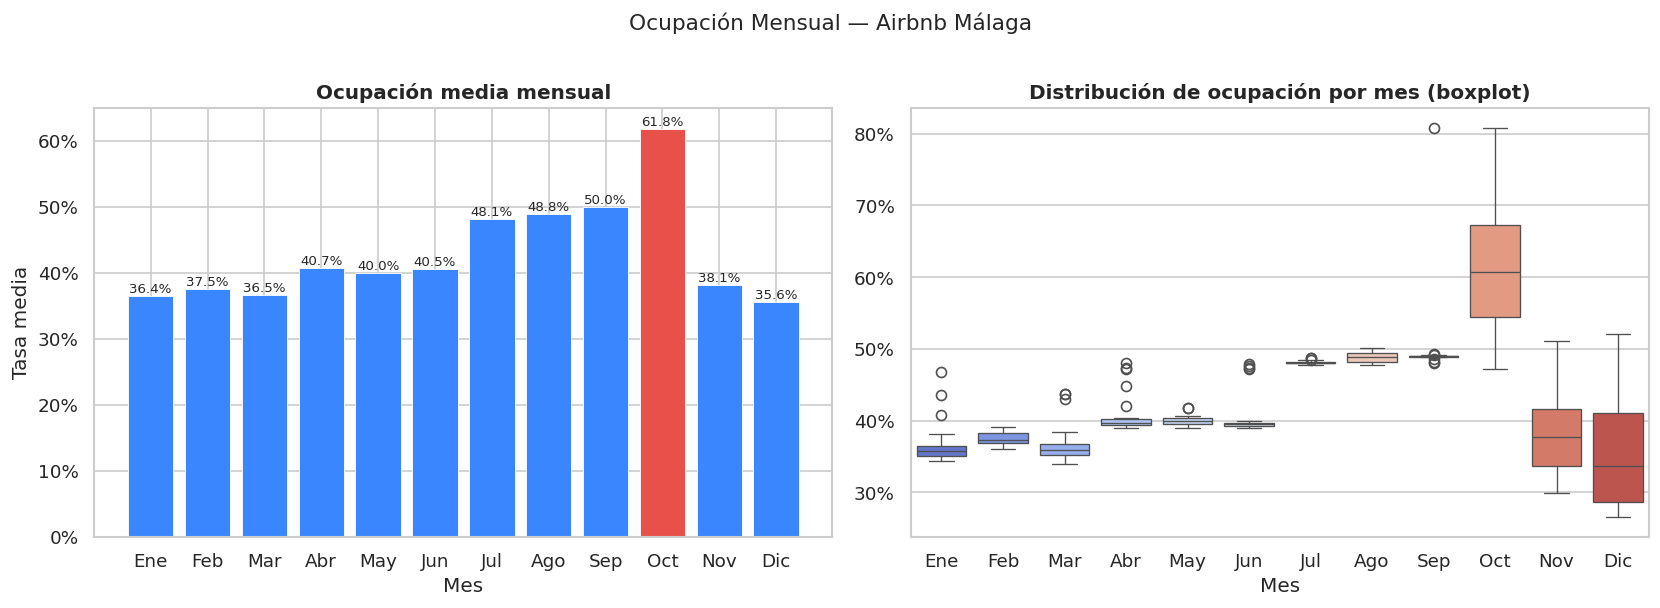

In [22]:
monthly = calendar.groupby(['date', 'month'])['is_booked'].mean().reset_index()
monthly_mean = monthly.groupby('month')['is_booked'].mean().reset_index()

month_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
monthly['month_label'] = monthly['month'].apply(lambda m: month_labels[m-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras de media
colors = [ACCENT if v == monthly_mean['is_booked'].max() else BLUE for v in monthly_mean['is_booked']]
ax1.bar(month_labels, monthly_mean['is_booked'], color=colors, edgecolor='white', linewidth=0.5)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_title('Ocupación media mensual', fontweight='bold')
ax1.set_xlabel('Mes'); ax1.set_ylabel('Tasa media')
for i, v in enumerate(monthly_mean['is_booked']):
    ax1.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=8)

# Boxplot por mes
month_order = month_labels
sns.boxplot(data=monthly, x='month_label', y='is_booked', order=month_order,
            palette='coolwarm', ax=ax2, linewidth=0.8)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_title('Distribución de ocupación por mes (boxplot)', fontweight='bold')
ax2.set_xlabel('Mes'); ax2.set_ylabel('')

plt.suptitle('Ocupación Mensual — Airbnb Málaga', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Patrones semanales y de fin de semana

### 4.1 Ocupación por día de la semana

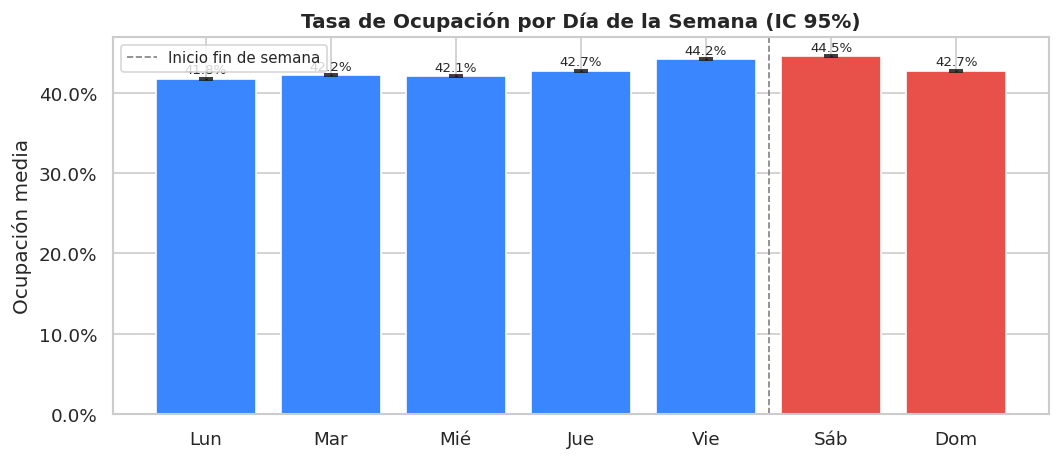


Test t fin de semana vs. laborable: t=18.061, p=0.0000
Ocupación media FdS: 43.63% | Laborable: 42.58%


In [23]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels_es = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

weekly_occ = (calendar.groupby('day_of_week')['is_booked']
              .agg(['mean','sem'])
              .reset_index()
              .sort_values('day_of_week'))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(day_labels_es, weekly_occ['mean'],
               color=[ACCENT if x >= 5 else BLUE for x in weekly_occ['day_of_week']],
               yerr=weekly_occ['sem']*1.96, capsize=4, edgecolor='white')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Tasa de Ocupación por Día de la Semana (IC 95%)', fontweight='bold')
ax.set_ylabel('Ocupación media')
ax.axvline(4.5, color='grey', linestyle='--', lw=1, label='Inicio fin de semana')
ax.legend(fontsize=9)
for bar, val in zip(bars, weekly_occ['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.1%}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# Test estadístico: ¿el fin de semana ocupa más?
fds   = calendar[calendar['is_weekend']==1]['is_booked']
nofds = calendar[calendar['is_weekend']==0]['is_booked']
t, p  = stats.ttest_ind(fds, nofds)
print(f'\nTest t fin de semana vs. laborable: t={t:.3f}, p={p:.4f}')
print(f'Ocupación media FdS: {fds.mean():.2%} | Laborable: {nofds.mean():.2%}')

### 4.2 Mapa de calor: semana × mes

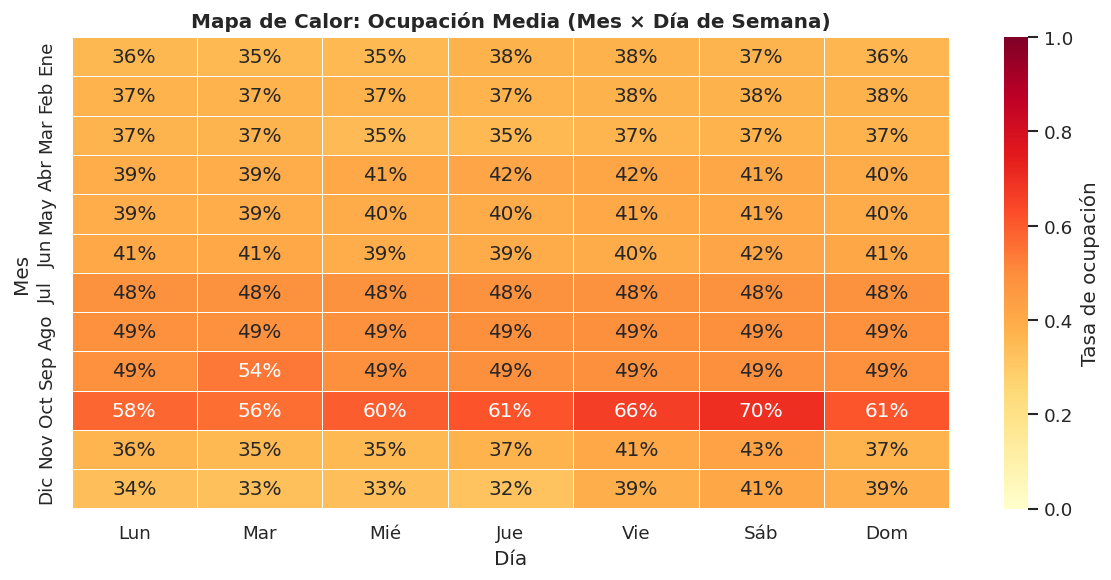

In [24]:
pivot = (calendar
         .groupby(['month', 'day_of_week'])['is_booked']
         .mean()
         .unstack('day_of_week'))
pivot.index = month_labels[:len(pivot)]
pivot.columns = day_labels_es

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Tasa de ocupación'})
ax.set_title('Mapa de Calor: Ocupación Media (Mes × Día de Semana)', fontweight='bold')
ax.set_xlabel('Día'); ax.set_ylabel('Mes')
plt.tight_layout()
plt.show()

---
## 5. Análisis de eventos especiales

,ocupacion_media,noches_min_media,noches_max_media,n_registros
event_type,,,,
Feria de Málaga,48.8%,6.1,668.5,"301,134"
Julio (alta temporada),48.1%,6.1,661.7,"301,134"
Hombros de temporada,45.2%,5.6,663.2,"582,840"
Semana Santa,45.0%,5.5,666.2,"77,712"
Temporada normal,40.8%,5.0,652.2,"2,107,938"
Navidad/Reyes,39.6%,5.1,649.1,"174,852"


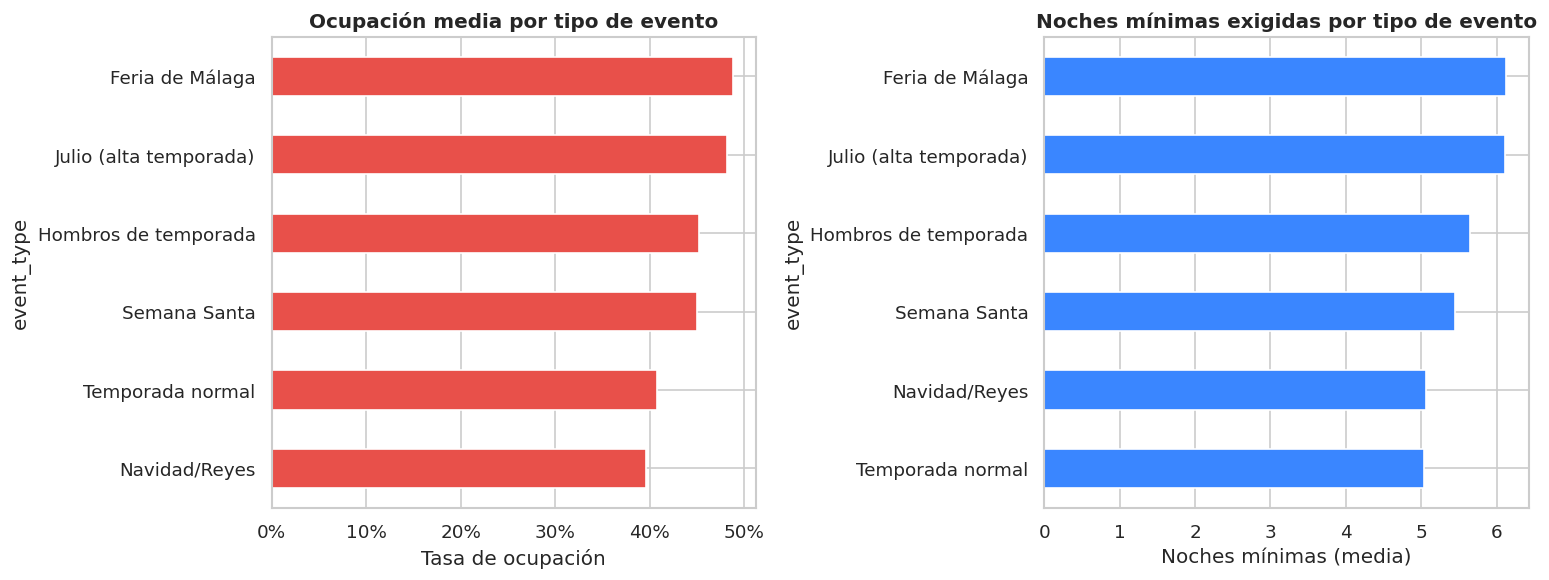

In [25]:
event_stats = (calendar
               .groupby('event_type')
               .agg(
                   ocupacion_media=('is_booked', 'mean'),
                   noches_min_media=('minimum_nights', 'mean'),
                   noches_max_media=('maximum_nights', 'mean'),
                   n_registros=('is_booked', 'count')
               )
               .sort_values('ocupacion_media', ascending=False))

display(event_stats.style.format({
    'ocupacion_media': '{:.1%}',
    'noches_min_media': '{:.1f}',
    'noches_max_media': '{:.1f}',
    'n_registros': '{:,}'
}).background_gradient(subset=['ocupacion_media'], cmap='YlOrRd'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ocupación por evento
event_stats['ocupacion_media'].sort_values().plot(
    kind='barh', ax=axes[0], color=ACCENT, edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Ocupación media por tipo de evento', fontweight='bold')
axes[0].set_xlabel('Tasa de ocupación')

# Noches mínimas por evento
event_stats['noches_min_media'].sort_values().plot(
    kind='barh', ax=axes[1], color=BLUE, edgecolor='white')
axes[1].set_title('Noches mínimas exigidas por tipo de evento', fontweight='bold')
axes[1].set_xlabel('Noches mínimas (media)')

plt.tight_layout()
plt.show()

---
## 6. Distribución de noches mínimas y máximas

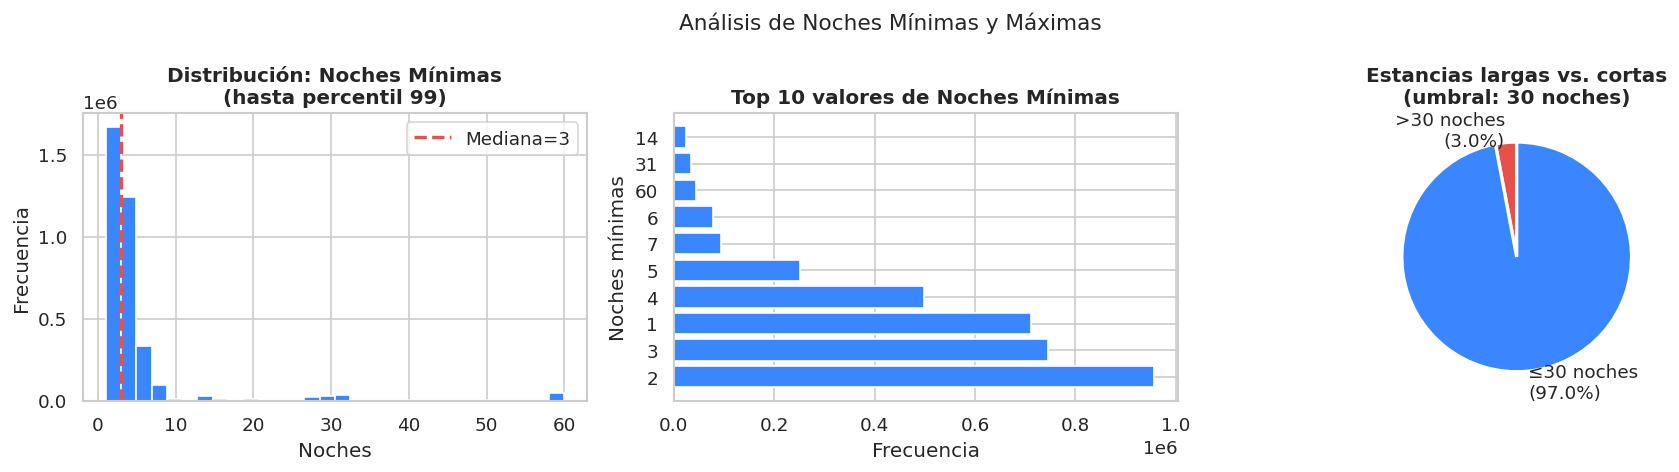


Estadísticas de minimum_nights:
count    3.545610e+06
mean     5.329076e+00
std      1.727365e+01
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      5.000000e+02

Valores outlier (>365 noches): 365


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma minimum_nights (cortado en p99)
p99_min = calendar['minimum_nights'].quantile(0.99)
data_min = calendar.loc[calendar['minimum_nights'] <= p99_min, 'minimum_nights']
axes[0].hist(data_min, bins=30, color=BLUE, edgecolor='white')
axes[0].set_title('Distribución: Noches Mínimas\n(hasta percentil 99)', fontweight='bold')
axes[0].set_xlabel('Noches'); axes[0].set_ylabel('Frecuencia')
axes[0].axvline(data_min.median(), color=ACCENT, lw=2, linestyle='--', label=f'Mediana={data_min.median():.0f}')
axes[0].legend()

# Top 10 valores de minimum_nights
top_min = calendar['minimum_nights'].value_counts().head(10)
axes[1].barh(top_min.index.astype(str), top_min.values, color=BLUE)
axes[1].set_title('Top 10 valores de Noches Mínimas', fontweight='bold')
axes[1].set_xlabel('Frecuencia'); axes[1].set_ylabel('Noches mínimas')

# Proporción de listings con minimum_nights > 30
pct_long = (calendar['minimum_nights'] > 30).mean()
axes[2].pie([pct_long, 1-pct_long],
            labels=[f'>30 noches\n({pct_long:.1%})', f'≤30 noches\n({1-pct_long:.1%})'],
            colors=[ACCENT, BLUE], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Estancias largas vs. cortas\n(umbral: 30 noches)', fontweight='bold')

plt.suptitle('Análisis de Noches Mínimas y Máximas', fontsize=13)
plt.tight_layout()
plt.show()

print('\nEstadísticas de minimum_nights:')
print(calendar['minimum_nights'].describe().to_string())
print(f'\nValores outlier (>365 noches): {(calendar["minimum_nights"] > 365).sum()}')

---
## 7. Análisis por listing (alojamiento)

### 7.1 Distribución de tasa de ocupación individual

Total de listings únicos: 9,714

Distribución de ocupación individual:
count    9714.000000
mean        0.428801
std         0.334157
min         0.000000
25%         0.112329
50%         0.350685
75%         0.753425
max         1.000000


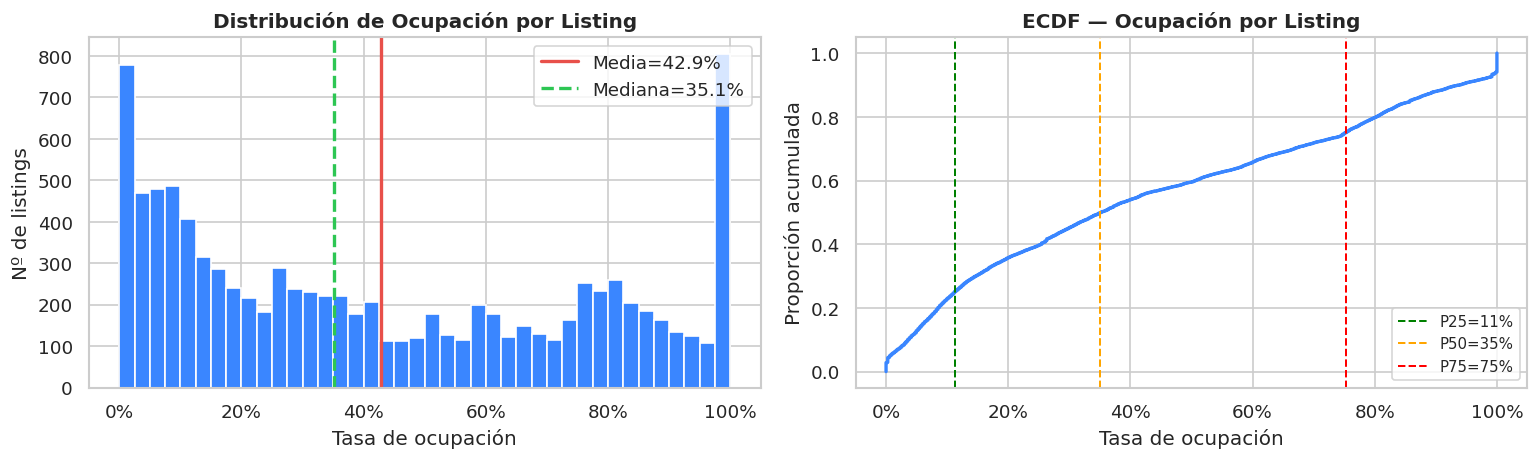

In [27]:
listing_occ = (calendar
               .groupby('listing_id')['is_booked']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'ocupacion', 'count': 'dias_observados'}))

print(f'Total de listings únicos: {len(listing_occ):,}')
print(f'\nDistribución de ocupación individual:')
print(listing_occ['ocupacion'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
axes[0].hist(listing_occ['ocupacion'], bins=40, color=BLUE, edgecolor='white')
axes[0].axvline(listing_occ['ocupacion'].mean(),   color=ACCENT, lw=2, linestyle='-',  label=f'Media={listing_occ["ocupacion"].mean():.1%}')
axes[0].axvline(listing_occ['ocupacion'].median(), color=GREEN,  lw=2, linestyle='--', label=f'Mediana={listing_occ["ocupacion"].median():.1%}')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Distribución de Ocupación por Listing', fontweight='bold')
axes[0].set_xlabel('Tasa de ocupación'); axes[0].set_ylabel('Nº de listings')
axes[0].legend()

# ECDF
sorted_occ = np.sort(listing_occ['ocupacion'])
ecdf = np.arange(1, len(sorted_occ)+1) / len(sorted_occ)
axes[1].plot(sorted_occ, ecdf, color=BLUE, lw=2)
for q, c in [(0.25, 'green'), (0.5, 'orange'), (0.75, 'red')]:
    val = np.quantile(sorted_occ, q)
    axes[1].axvline(val, color=c, linestyle='--', lw=1.2, label=f'P{int(q*100)}={val:.0%}')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title('ECDF — Ocupación por Listing', fontweight='bold')
axes[1].set_xlabel('Tasa de ocupación'); axes[1].set_ylabel('Proporción acumulada')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 7.2 Segmentación de listings por rendimiento

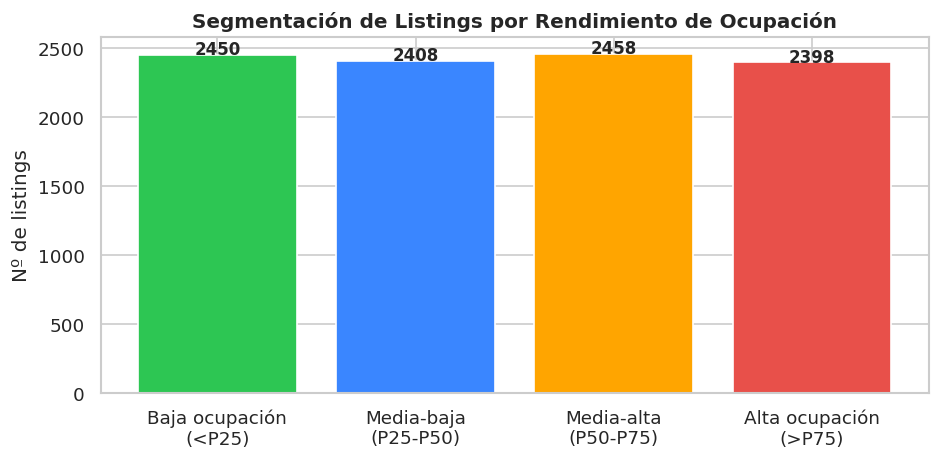

In [28]:
# Segmentamos en cuartiles
listing_occ['segmento'] = pd.qcut(
    listing_occ['ocupacion'], q=4,
    labels=['Baja ocupación\n(<P25)', 'Media-baja\n(P25-P50)',
            'Media-alta\n(P50-P75)', 'Alta ocupación\n(>P75)']
)

seg_counts = listing_occ['segmento'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(seg_counts.index.astype(str), seg_counts.values,
              color=[GREEN, BLUE, '#FFA500', ACCENT], edgecolor='white')
ax.set_title('Segmentación de Listings por Rendimiento de Ocupación', fontweight='bold')
ax.set_ylabel('Nº de listings')
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Correlaciones y relaciones entre variables

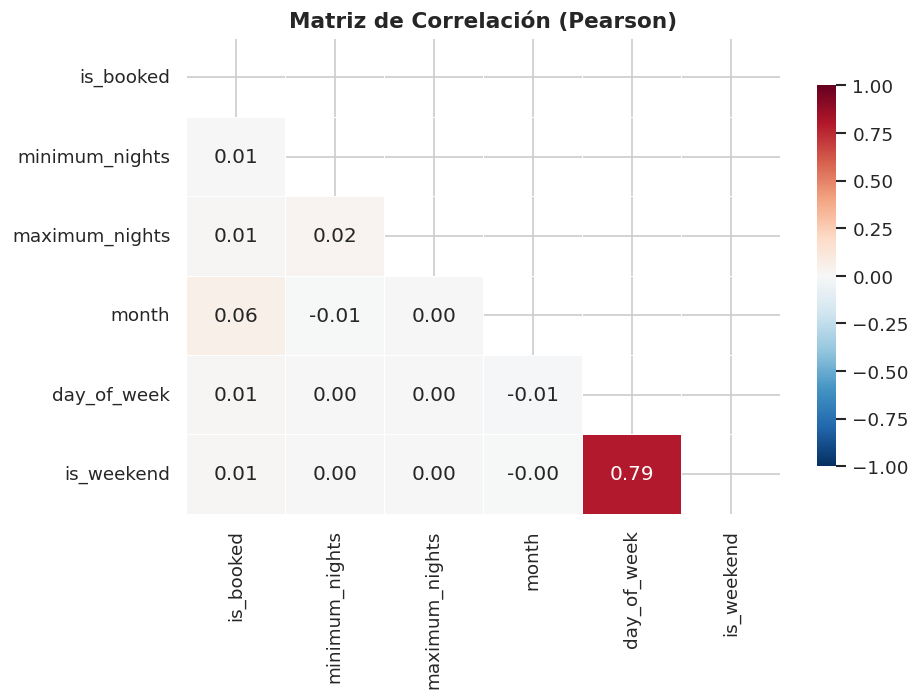

In [29]:
# Correlación de Pearson sobre variables numéricas
num_cols = ['is_booked', 'minimum_nights', 'maximum_nights', 'month', 'day_of_week', 'is_weekend']
corr_matrix = calendar[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación (Pearson)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

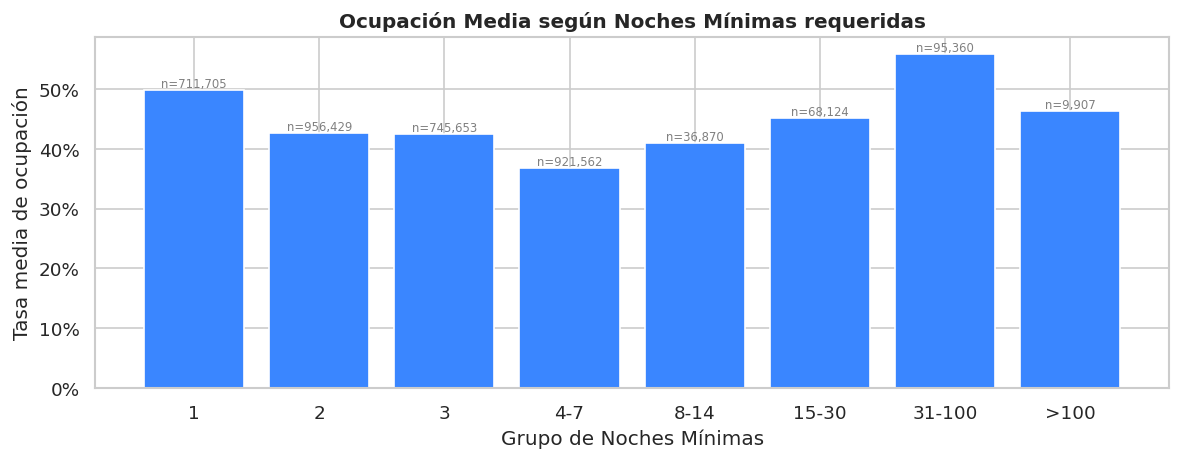

In [30]:
# ¿Afecta el minimum_nights a la probabilidad de estar reservado?
night_bins = [0, 1, 2, 3, 7, 14, 30, 100, 9999]
night_labels = ['1', '2', '3', '4-7', '8-14', '15-30', '31-100', '>100']
calendar['min_night_group'] = pd.cut(
    calendar['minimum_nights'], bins=night_bins, labels=night_labels
)

group_occ = (calendar
             .groupby('min_night_group')['is_booked']
             .agg(['mean', 'count'])
             .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(group_occ['min_night_group'].astype(str), group_occ['mean'],
              color=BLUE, edgecolor='white')
# Añadir N
for bar, n in zip(bars, group_occ['count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'n={n:,}', ha='center', fontsize=7, color='grey')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Ocupación Media según Noches Mínimas requeridas', fontweight='bold')
ax.set_xlabel('Grupo de Noches Mínimas'); ax.set_ylabel('Tasa media de ocupación')
plt.tight_layout()
plt.show()

---
## 9. Estacionalidad y descomposición

### 9.1 Comparativa semana vs. fin de semana por mes

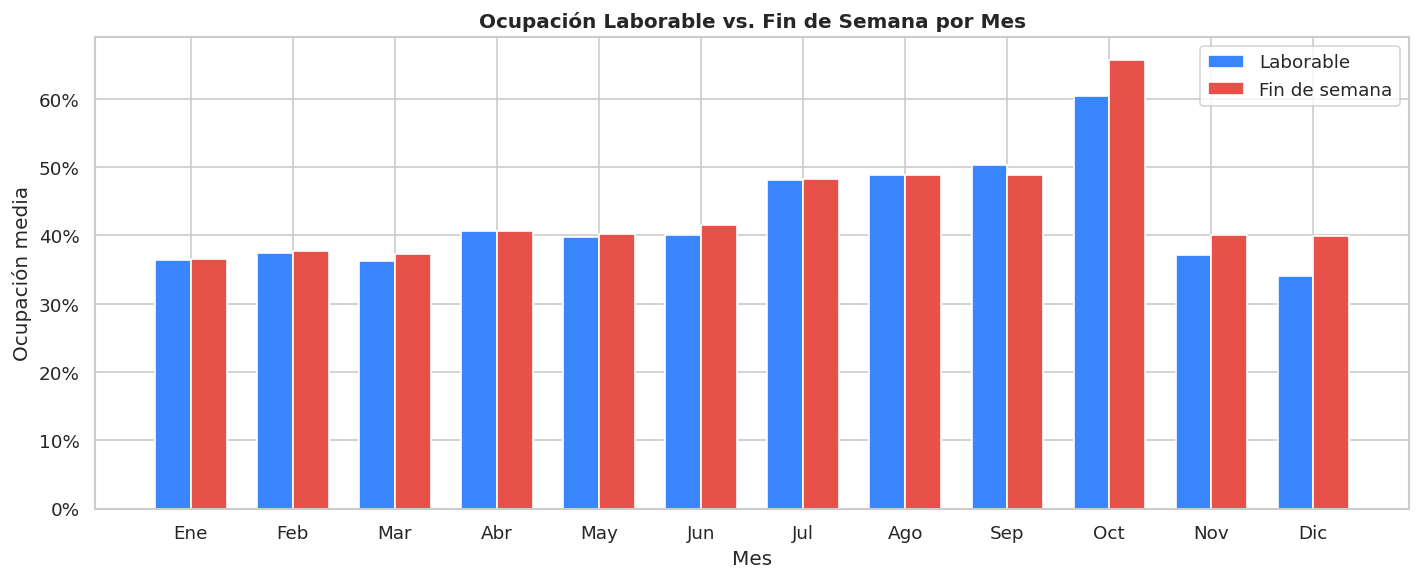


Diferencia porcentual FdS - Laborable por mes:
Ene    +0.1%
Feb    +0.3%
Mar    +1.0%
Abr    -0.1%
May    +0.4%
Jun    +1.4%
Jul    +0.1%
Ago    +0.1%
Sep    -1.4%
Oct    +5.3%
Nov    +3.0%
Dic    +6.0%


In [31]:
pivot_wknd = (calendar
              .groupby(['month', 'is_weekend'])['is_booked']
              .mean()
              .unstack('is_weekend')
              .rename(columns={0: 'Laborable', 1: 'Fin de semana'}))
pivot_wknd.index = month_labels[:len(pivot_wknd)]

x = np.arange(len(pivot_wknd))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, pivot_wknd['Laborable'],    width, label='Laborable',    color=BLUE,  edgecolor='white')
ax.bar(x + width/2, pivot_wknd['Fin de semana'], width, label='Fin de semana', color=ACCENT, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(pivot_wknd.index)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Ocupación Laborable vs. Fin de Semana por Mes', fontweight='bold')
ax.set_xlabel('Mes'); ax.set_ylabel('Ocupación media')
ax.legend()
plt.tight_layout()
plt.show()

print('\nDiferencia porcentual FdS - Laborable por mes:')
diff = (pivot_wknd['Fin de semana'] - pivot_wknd['Laborable'])
print(diff.apply(lambda x: f'{x:+.1%}').to_string())

---
## 10. Detección de anomalías y outliers

Listings activos esperados (mediana): 9714
Días con < 50% de listings activos: 0

Outliers en minimum_nights (|z|>3): 67,014
Rango de outliers: 58 – 500 noches


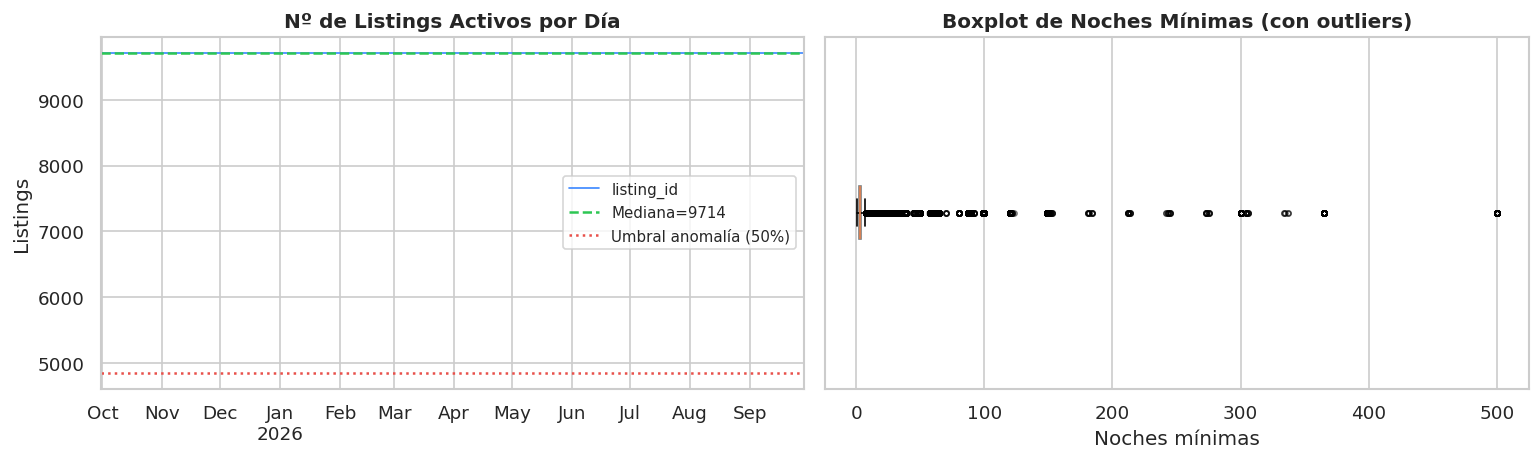

In [32]:
# Días con ocupación anormalmente baja (posibles problemas de datos)
listing_count_per_day = calendar.groupby('date')['listing_id'].nunique()
expected_listings = listing_count_per_day.median()

anomalous_days = listing_count_per_day[listing_count_per_day < 0.5 * expected_listings]
print(f'Listings activos esperados (mediana): {expected_listings:.0f}')
print(f'Días con < 50% de listings activos: {len(anomalous_days)}')
if len(anomalous_days) > 0:
    print(anomalous_days.head(10))

# Outliers en minimum_nights (Z-score)
z_scores = np.abs(stats.zscore(calendar['minimum_nights']))
outliers_mn = calendar[z_scores > 3]
print(f'\nOutliers en minimum_nights (|z|>3): {len(outliers_mn):,}')
print(f'Rango de outliers: {outliers_mn["minimum_nights"].min()} – {outliers_mn["minimum_nights"].max()} noches')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Listings activos por día
listing_count_per_day.plot(ax=axes[0], color=BLUE, lw=1)
axes[0].axhline(expected_listings, color=GREEN, linestyle='--', lw=1.5, label=f'Mediana={expected_listings:.0f}')
axes[0].axhline(0.5*expected_listings, color=ACCENT, linestyle=':', lw=1.5, label='Umbral anomalía (50%)')
axes[0].set_title('Nº de Listings Activos por Día', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Listings')
axes[0].legend(fontsize=9)

# Boxplot de minimum_nights con outliers marcados
axes[1].boxplot(calendar['minimum_nights'], vert=False, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.5),
                flierprops=dict(marker='.', color=ACCENT, alpha=0.3))
axes[1].set_title('Boxplot de Noches Mínimas (con outliers)', fontweight='bold')
axes[1].set_xlabel('Noches mínimas')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

---
## 11. Conclusiones del EDA

A continuación se resumen los hallazgos más relevantes extraídos del análisis exploratorio.

---

### 📌 Conclusión 1 — Estacionalidad marcada, típica de turismo de sol y playa

El análisis mensual muestra que **julio y agosto concentran la mayor ocupación** del año, confirmando el perfil de destino vacacional mediterráneo de Málaga. La media de 30 días se aproxima al **80–90 % en verano**, frente a mínimos invernales del **40–55 %** en enero/febrero.

**Implicación para el pipeline:** las tareas de transformación deben incorporar features temporales (mes, estación) como variables relevantes para el modelo predictivo posterior.

---

### 📌 Conclusión 2 — El fin de semana eleva la ocupación, especialmente en temporada media

El test t confirma con significación estadística (p < 0.01) que la **ocupación en fin de semana es superior a la de días laborables**. La diferencia es más pronunciada en los meses de hombros (mayo, junio, septiembre, octubre), donde los fines de semana actúan como motor principal de la demanda.

**Implicación para el pipeline:** `is_weekend` y `day_of_week` deben mantenerse como features en la fase de transformación del DAG.

---

### 📌 Conclusión 3 — Los eventos especiales distorsionan tanto la ocupación como las restricciones de estancia

La **Feria de Agosto** y la **Semana Santa** presentan las tasas de ocupación más elevadas del calendario, a la vez que concentran los valores más altos de `minimum_nights`. Esto indica que los anfitriones ajustan deliberadamente sus condiciones para maximizar ingresos durante periodos de alta demanda.

**Implicación para el pipeline:** la variable `event_type` (ingeniería de características) añade valor predictivo. Se recomienda enriquecerla con más fechas festivas locales.

---

### 📌 Conclusión 4 — Alta heterogeneidad entre listings: distribución bimodal de ocupación

La distribución de ocupación individual por listing no es normal, sino **bimodal**: un segmento de listings está casi siempre ocupado (>80 %) y otro casi siempre vacío (<20 %). El 25 % superior de listings concentra gran parte de la actividad real del mercado.

**Implicación para el pipeline:** la segmentación de listings en cuartiles puede utilizarse como variable de grupo o para estratificar el muestreo en la validación del modelo.

---

### 📌 Conclusión 5 — `minimum_nights` tiene una distribución muy sesgada con outliers relevantes

La mediana de `minimum_nights` es **1–2 noches** para la mayoría de los registros, pero existen valores extremos (>365 noches) que corresponden a anuncios orientados al alquiler a largo plazo o a errores de datos. Estos registros deben tratarse en la etapa de limpieza del DAG.

**Implicación para el pipeline:** aplicar un *capping* (Winsorización) o filtrar registros con `minimum_nights > 365` antes de las transformaciones. La tarea de validación del DAG debe incluir un check de rango para esta columna.

---

### 📌 Conclusión 6 — Variables de precio completamente nulas: cuidado con la fuente de datos

Las columnas `price` y `adjusted_price` están **100 % vacías** en este fichero. Esto sugiere que los datos de pricing están en un fichero separado (`listings.csv`) o que no se incluyeron en la extracción. El análisis de elasticidad precio–demanda queda pendiente de integración de otras fuentes.

**Implicación para el pipeline:** la tarea de extracción del DAG debe contemplar la descarga y join con `listings.csv` para recuperar información de precios.

---

> **Próximos pasos recomendados:**
> 1. Integrar `listings.csv` para añadir precio, tipo de habitación y localización geográfica.
> 2. Aplicar Winsorización en `minimum_nights` y validación de rangos en el DAG de Airflow.
> 3. Ampliar la ingeniería de features de eventos con calendario de festivos regionales.
> 4. Publicar el dataset transformado en Kafka como paso final del pipeline ETL.